# Testing
## Geburten nach Monat, Stadtquartier, Geschlecht, Altersgruppe und Herkunft, seit 1998
Datum: 21.01.2022

### Importiere die notwendigen Packages

In [10]:
import pandas as pd
#from pivottablejs import pivot_ui
import numpy as np
import altair as alt
import matplotlib.pyplot as plt
#from datetime import datetime
import datetime
from dateutil.relativedelta import *
import geopandas as gpd
import folium 
import plotly.express as px


Definiere Settings. Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen), 

In [11]:
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

### Zeitvariabeln
Bestimme den aktuellst geladenen Monat. Hier ist es der Stand vor 2 Monaten. 
Bestimme noch weitere evt. sinnvolle Zeitvariabeln.

Zum Unterschied zwischen import datetime und from datedtime import datetime, siehe https://stackoverflow.com/questions/15707532/import-datetime-v-s-from-datetime-import-datetime

#### Zuerst die generellen Zeitvariabeln als Strings

In [12]:
#today_date = datetime.date.today()
#date_time = datetime.datetime.strptime(date_time_string, '%Y-%m-%d %H:%M')
now = datetime.date.today()
date_today = now.strftime("%Y-%m-%d")
year_today = now.strftime("%Y")
year_month_today = now.strftime("%Y-%m")
month_today = now.strftime("%Y")
day_today = now.strftime("%d")
date_day_a_week_ago = (datetime.datetime.now() - datetime.timedelta(days=7)).date()
day_a_week_ago = date_day_a_week_ago.strftime('%Y-%m-%d')

#### Die zu testenden Zeitvariabeln als Strings

Hier mal die folgenden:
- `latest_year_month`: Der aktuellste Datenstand sollte ja immer der heutige Monat minus 2 sein.
- `latest_year`: Der aktuellste Datenstand sollte ja immer der heutige Monat minus 2 sein. Hier wird das damalige Jahr angegeben.
- `five_years_ago`: Und damit nicht immer alle Zeitreihen geprüft werden müssen, kann auch das Jahr vor 5 Jahren definiert werden.

In [13]:
#from datetime import datetime, timedelta
#from dateutil.relativedelta import *

latest_year_month = now + relativedelta(months=-2)
latest_year_month = latest_year_month.strftime("%Y-%m")
print(latest_year_month)

latest_year = now + relativedelta(months=-2)
latest_year = latest_year.strftime("%Y")
print(latest_year)

five_years_ago  = now + relativedelta(years=-5)
five_years_ago = five_years_ago.strftime("%Y")
print(five_years_ago)

2024-08
2024
2019


#### Und hier noch die Zeitvariabeln als Integers:
- `aktuellesJahr`
- `aktuellerMonat`: Der gerade jetzt aktuelle Monat
- `selectedMonat`: Der aktuellste Monat in den Daten. In der Regel zwei Monate her.

In [14]:
#now = datetime.now() 
int_times = now.timetuple()

aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2

print(aktuellesJahr, 
      aktuellerMonat,
    'datenstand: ', selectedMonat,
     int_times)


2024 10 datenstand:  8 time.struct_time(tm_year=2024, tm_mon=10, tm_mday=15, tm_hour=0, tm_min=0, tm_sec=0, tm_wday=1, tm_yday=289, tm_isdst=-1)


Berechne die Variable Epoche um später das SAS-Datum in ein Unix-Datum umzuwandeln. Bei SAS beginnt die Epoche am 1.1.1960. Bei Unix am 1.1.1970.
Diese Variable wird beim CSV-Import benötigt.

In [15]:
epoch = datetime.datetime(1960, 1, 1)

### Importiere einen Datensatz 

- Beachte dabei die Notation des Pfades...
- Definiere mal aktuell noch keine weiteren Parameter beim Import

**Dataset auf INTEG Datenkatalog**:  https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_monat_geburten_quartier_geschl_ag_herkunft_od4030

**Dataset auf PROD Datenkatalog**:  https://data.stadt-zuerich.ch/dataset/bev_monat_geburten_quartier_geschl_ag_herkunft_od4030

In [16]:
#Die Datasets sind nur zum Testen auf INT-DWH-Dropzone. Wenn der Test vorbei ist, sind sie auf PROD. 
# Über den Status kann man einfach switchen

status = "prod";
print(status)

prod


In [17]:
# Filepath
if status == "prod":
    #fp = r"//szh.loc/ssz/applikationen/OGD_Dropzone/DWH/bev_monat_bestand_quartier_geschl_ag_herkunft_od3250/BEV325OD3250.csv"
    fp = r"https://data.stadt-zuerich.ch/dataset/bev_monat_geburten_quartier_geschl_ag_herkunft_od4030/download/BEV403OD4030.csv"
else:  
    #Bezieht sich hier auf die Dropzone...
    fp = r"//szh.loc/ssz/applikationen/OGD_Dropzone/INT_DWH/bev_monat_geburten_quartier_geschl_ag_herkunft_od4030/BEV403OD4030.csv"

print(fp)

https://data.stadt-zuerich.ch/dataset/bev_monat_geburten_quartier_geschl_ag_herkunft_od4030/download/BEV403OD4030.csv


Beachte, wie das SAS Datum (ohne Format) in ein UNIX Datum umgerechnet und als Datumsformat dargestellt wird! Siehe dazu `https://stackoverflow.com/questions/26923564/convert-sas-numeric-to-python-datetime`

ACHTUNG: ist seit Juni 2023 nicht mehr notwendig, da die Datumsformate nun in ISO-8401 geliefert werden.

In [18]:
# Read the data
data2betested = pd.read_csv(
    fp, 
    sep=',',
    parse_dates=['StichtagDat'],
    # KONVERTIERE DAS SAS DATUM IN EIN UNIXDATUM UND FORMATIERE ES
    #date_parser=lambda s: epoch + datetime.timedelta(days=int(s)),
    low_memory=False    
    )

print('done')


done


In der Folge ein paar erste Tests:

 - 1) Zeige eine kurze Vorschau der importierten Daten
 - 2) Weise die Datentypen aus
 - 3) Zeige die Shape (Umfang) des Datensatzes an

In [19]:
latest_data_month = data2betested.reset_index().StichtagDat.max()
str_latest_data_month= str(latest_data_month)
print("Der aktuellste Monat im Datensatz ist: "+ str_latest_data_month)

Der aktuellste Monat im Datensatz ist: 2024-07-31 00:00:00


In [20]:
#data2betested.sort_values(by=['EreignisDatJahr','EreignisDatMM'], ascending=False).head(3)
data2betested.sort_values('StichtagDat', ascending=False).head(6)

,EreignisDatJahr,EreignisDatMM,EreignisDatMonat,StichtagDat,SexCd,SexLang,HerkunftCd,...,QuarCd,QuarLang,DatenstandCd,DatenstandLang,LebensfaehigkeitCd,LebensfaehigkeitLang,AnzGebuWir
33020,2024,7,Juli,2024-07-31,2,weiblich,2,...,123,Hirzenbach,P,Provisorisch,J,zutreffend,3
32957,2024,7,Juli,2024-07-31,1,männlich,2,...,81,Seefeld,P,Provisorisch,J,zutreffend,1
32947,2024,7,Juli,2024-07-31,1,männlich,1,...,122,Schwamendingen-Mitte,P,Provisorisch,J,zutreffend,2
32948,2024,7,Juli,2024-07-31,1,männlich,1,...,123,Hirzenbach,P,Provisorisch,J,zutreffend,5
32949,2024,7,Juli,2024-07-31,1,männlich,2,...,23,Leimbach,P,Provisorisch,J,zutreffend,2
32950,2024,7,Juli,2024-07-31,1,männlich,2,...,31,Alt-Wiedikon,P,Provisorisch,J,zutreffend,1


In [21]:
data2betested.dtypes

EreignisDatJahr                  int64
EreignisDatMM                    int64
EreignisDatMonat                object
StichtagDat             datetime64[ns]
SexCd                            int64
SexLang                         object
HerkunftCd                       int64
HerkunftLang                    object
KreisCd                          int64
KreisLang                       object
QuarCd                           int64
QuarLang                        object
DatenstandCd                    object
DatenstandLang                  object
LebensfaehigkeitCd              object
LebensfaehigkeitLang            object
AnzGebuWir                       int64
dtype: object

In [22]:
data2betested.shape

(33021, 17)

Beschreibe einzelne Attribute

In [23]:
data2betested.describe()

,EreignisDatJahr,EreignisDatMM,StichtagDat,SexCd,HerkunftCd,KreisCd,QuarCd,AnzGebuWir
count,33021,33021,33021,33021,33021,33021,33021,33021
mean,2011,6,2011-08-04 11:10:34.178250496,1,1,7,71,4
min,1998,1,1998-01-31 00:00:00,1,1,1,11,1
25%,2005,3,2005-01-31 00:00:00,1,1,4,42,2
50%,2011,6,2011-09-30 00:00:00,1,1,7,72,3
75%,2018,9,2018-02-28 00:00:00,2,2,10,102,5
max,2024,12,2024-07-31 00:00:00,2,2,12,123,25
std,8,3,NaN,0,0,3,34,3


Wie viele Nullwerte gibt es im Datensatz?

In [24]:
data2betested.isnull().sum()

EreignisDatJahr         0
EreignisDatMM           0
EreignisDatMonat        0
StichtagDat             0
SexCd                   0
SexLang                 0
HerkunftCd              0
HerkunftLang            0
KreisCd                 0
KreisLang               0
QuarCd                  0
QuarLang                0
DatenstandCd            0
DatenstandLang          0
LebensfaehigkeitCd      0
LebensfaehigkeitLang    0
AnzGebuWir              0
dtype: int64

### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [25]:
data2betested = data2betested.set_index("StichtagDat")
#data2betested = data2betested.drop(columns=["StichtagDatMM"])


In [26]:
data2betested.info()
data2betested.index.day.unique()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 33021 entries, 1998-01-31 to 2024-07-31
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   EreignisDatJahr       33021 non-null  int64 
 1   EreignisDatMM         33021 non-null  int64 
 2   EreignisDatMonat      33021 non-null  object
 3   SexCd                 33021 non-null  int64 
 4   SexLang               33021 non-null  object
 5   HerkunftCd            33021 non-null  int64 
 6   HerkunftLang          33021 non-null  object
 7   KreisCd               33021 non-null  int64 
 8   KreisLang             33021 non-null  object
 9   QuarCd                33021 non-null  int64 
 10  QuarLang              33021 non-null  object
 11  DatenstandCd          33021 non-null  object
 12  DatenstandLang        33021 non-null  object
 13  LebensfaehigkeitCd    33021 non-null  object
 14  LebensfaehigkeitLang  33021 non-null  object
 15  AnzGebuWir         

Index([31, 28, 30, 29], dtype='int32', name='StichtagDat')

### Einfache Visualisierungen zur Plausi

Exploriere die Daten mit Pivottable.JS

In [27]:
#from pivottablejs import pivot_ui

#pivot_ui(data2betested)

### Zeitpunkte und Zeiträume abfragen

A particular powerful feature of the Pandas DataFrame is its indexing capability that also works using time-based entities, such as dates and times. We have already created the index above, so let's put it to use.

In [28]:
data2betested.loc[latest_year_month].head(4)
#data2betested.loc["2021-10-31":"2021-11-30"].head(2)


KeyError: '2024-08'

### Aggregiere Werte nach Zeitausschnitten

Mit den Funktionen zur Zeit kann einfach zwischen Stunden, Tagen, Monaten, etc. gewechselt und aggregiert werden.
Da die Daten bereits aggregiert nach Monaten sind, macht das hier keinen Sinn.
Untenstehendes also nur als BSP


In [20]:
# first we create the sums per week
weekly_sums = data2betested.resample("W").sum()
# then we generate the weekly means for each quarter
data2betested_sel = data2betested[["SexCd","HerkunftCd","AnzGebuWir"]]
quarterly_sums = data2betested_sel.resample("Q").sum()
# for readability we'll revert the values back to integers
quarterly_sums.astype(int).head(3)

C:\Users\sszsim\AppData\Local\Temp\ipykernel_12712\3124077254.py:5: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_sums = data2betested_sel.resample("Q").sum()


,SexCd,HerkunftCd,AnzGebuWir
StichtagDat,,,
1998-03-31,434,415,906
1998-06-30,454,445,880
1998-09-30,427,420,865


### Visualisierungen nach Zeitausschnitten

In [21]:
data2betested.info()
#data2betested

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 32804 entries, 1998-01-31 to 2024-05-31
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   EreignisDatJahr       32804 non-null  int64 
 1   EreignisDatMM         32804 non-null  int64 
 2   EreignisDatMonat      32804 non-null  object
 3   SexCd                 32804 non-null  int64 
 4   SexLang               32804 non-null  object
 5   HerkunftCd            32804 non-null  int64 
 6   HerkunftLang          32804 non-null  object
 7   KreisCd               32804 non-null  int64 
 8   KreisLang             32804 non-null  object
 9   QuarCd                32804 non-null  int64 
 10  QuarLang              32804 non-null  object
 11  DatenstandCd          32804 non-null  object
 12  DatenstandLang        32804 non-null  object
 13  LebensfaehigkeitCd    32804 non-null  object
 14  LebensfaehigkeitLang  32804 non-null  object
 15  AnzGebuWir         

#### Entwicklung Geburten nach Stadtkreis

In [47]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg = data2betested \
    .groupby(['StichtagDat','EreignisDatJahr', 'EreignisDatMM','KreisLang']) \
    .agg(sum_WBev=('AnzGebuWir', 'sum')) \
    .sort_values('StichtagDat', ascending=False) 

myAgg.reset_index().sort_values('EreignisDatJahr', ascending=False).head(3)

,StichtagDat,EreignisDatJahr,EreignisDatMM,KreisLang,sum_WBev
0,2024-05-31,2024,5,Kreis 9,38
31,2024-03-31,2024,3,Kreis 4,20
33,2024-03-31,2024,3,Kreis 6,41


In [23]:
myTitle="Geburten nach Stadtkreis"

highlight = alt.selection(type='single', on='mouseover',
                          fields=['KreisLang'], nearest=True)
#x='date:StichtagDatJahr',
base = alt.Chart(myAgg.loc["2020-11":latest_year_month].reset_index().query('sum_WBev>0'), title=myTitle).encode(
    x=alt.X('StichtagDat', axis=alt.Axis(title='Jahr'))# , axis=alt.Axis(format='%', title='percentage')
    , y=alt.X('sum_WBev', axis=alt.Axis(title='Anz. Personen'))
    , color=alt.Color('KreisLang', legend=alt.Legend(title="Stadtkreise", orient="right"))  
    ,tooltip=['StichtagDat', 'KreisLang', 'sum_WBev']    
)
points = base.mark_circle().encode(
    opacity=alt.value(0.75)
).add_selection(
    highlight
).properties(
    width=900 , height=350
)
lines = base.mark_line().encode(
    size=alt.condition(~highlight, alt.value(1.5), alt.value(4))
).interactive()

lines + points

c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\deprecation.py:65: AltairDeprecationWarning: 'selection' is deprecated.
   Use 'selection_point()' or 'selection_interval()' instead; these functions also include more helpful docstrings.
  warnings.warn(message, AltairDeprecationWarning, stacklevel=1)
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\vegalite\v5\api.py:425: AltairDeprecationWarning: The types 'single' and 'multi' are now
        combined and should be specified using "selection_point()".
  warnings.warn(
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\deprecation.py:65: AltairDeprecationWarning: 'add_selection' is deprecated. Use 'add_params' instead.
  warnings.warn(message, AltairDeprecationWarning, stacklevel=1)
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is depre

alt.LayerChart(...)

#### Entwicklung nach Geschlecht

In [24]:
#myAgg = data2betested.loc["2008-11":"2021-11"] \
myAgg = data2betested \
    .groupby(['StichtagDat','EreignisDatJahr', 'EreignisDatMM', 'SexLang']) \
    .agg(sum_WBev=('AnzGebuWir', 'sum')) \
    .sort_values('sum_WBev', ascending=False) 

myAgg.reset_index().head(2)

,StichtagDat,EreignisDatJahr,EreignisDatMM,SexLang,sum_WBev
0,2021-01-31,2021,1,weiblich,344
1,2020-01-31,2020,1,männlich,338


In [25]:
myTitle="Geburten nach Geschlecht"
highlight = alt.selection(type='single', on='mouseover',
                          fields=['SexLang'], nearest=True)
#x='date:StichtagDatJahr',
base = alt.Chart(myAgg.reset_index().query('sum_WBev>1'), title=myTitle).encode(
    x=alt.X('StichtagDat', axis=alt.Axis(title='Jahr'))# , axis=alt.Axis(format='%', title='percentage')
    , y=alt.X('sum_WBev', axis=alt.Axis(title='Anz. Personen'))
    , color=alt.Color('SexLang', legend=alt.Legend(title="Geschlecht"))  
    ,tooltip=['StichtagDat', 'SexLang', 'sum_WBev']    
)
points = base.mark_circle().encode(
    opacity=alt.value(0.75)
).add_selection(
    highlight
).properties(
    width=900 , height=350
)
lines = base.mark_line().encode(
    size=alt.condition(~highlight, alt.value(0.5), alt.value(4))
).interactive()

lines + points

c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\deprecation.py:65: AltairDeprecationWarning: 'selection' is deprecated.
   Use 'selection_point()' or 'selection_interval()' instead; these functions also include more helpful docstrings.
  warnings.warn(message, AltairDeprecationWarning, stacklevel=1)
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\vegalite\v5\api.py:425: AltairDeprecationWarning: The types 'single' and 'multi' are now
        combined and should be specified using "selection_point()".
  warnings.warn(
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\deprecation.py:65: AltairDeprecationWarning: 'add_selection' is deprecated. Use 'add_params' instead.
  warnings.warn(message, AltairDeprecationWarning, stacklevel=1)
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is depre

alt.LayerChart(...)

#### Entwicklung nach Heimat

In [26]:
#myAgg = data2betested.loc["2008-11":"2021-11"] \
myAgg = data2betested \
    .groupby(['StichtagDat','EreignisDatJahr', 'EreignisDatMM', 'HerkunftLang']) \
    .agg(sum_WBev=('AnzGebuWir', 'sum')) \
    .sort_values('sum_WBev', ascending=False) 

myAgg.reset_index().head(2)

,StichtagDat,EreignisDatJahr,EreignisDatMM,HerkunftLang,sum_WBev
0,2020-01-31,2020,1,Schweizer*in,362
1,2019-01-31,2019,1,Schweizer*in,352


In [27]:
myTitle="Geburten nach Herkunft"

highlight = alt.selection(type='single', on='mouseover',
                          fields=['HerkunftLang'], nearest=True)
#x='date:StichtagDatJahr',
base = alt.Chart(myAgg.reset_index().query('sum_WBev>1'), title=myTitle).encode(
    x=alt.X('StichtagDat', axis=alt.Axis(title='Jahr'))# , axis=alt.Axis(format='%', title='percentage')
    , y=alt.X('sum_WBev', axis=alt.Axis(title='Anz. Personen'))
    , color=alt.Color('HerkunftLang', legend=alt.Legend(title="Herkunft"))  
    ,tooltip=['StichtagDat', 'HerkunftLang', 'sum_WBev']    
)
points = base.mark_circle().encode(
    opacity=alt.value(0.75)
).add_selection(
    highlight
).properties(
    width=900 , height=350
)
lines = base.mark_line().encode(
    size=alt.condition(~highlight, alt.value(0.5), alt.value(4))
).interactive()

lines + points    


c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\deprecation.py:65: AltairDeprecationWarning: 'selection' is deprecated.
   Use 'selection_point()' or 'selection_interval()' instead; these functions also include more helpful docstrings.
  warnings.warn(message, AltairDeprecationWarning, stacklevel=1)
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\vegalite\v5\api.py:425: AltairDeprecationWarning: The types 'single' and 'multi' are now
        combined and should be specified using "selection_point()".
  warnings.warn(
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\deprecation.py:65: AltairDeprecationWarning: 'add_selection' is deprecated. Use 'add_params' instead.
  warnings.warn(message, AltairDeprecationWarning, stacklevel=1)
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is depre

alt.LayerChart(...)

#### Geburten nach Geburtsmonat seit 2000

In [28]:
myAgg = data2betested.loc["2019-01":latest_year_month]  \
    .groupby(['StichtagDat','EreignisDatJahr', 'EreignisDatMM']) \
    .agg(sum_WBev=('AnzGebuWir', 'sum')) \
    .sort_values('sum_WBev', ascending=False) 

myAgg.reset_index().sort_values('StichtagDat',ascending=False).head(10)

,StichtagDat,EreignisDatJahr,EreignisDatMM,sum_WBev
48,2024-05-31,2024,5,361
56,2024-04-30,2024,4,346
55,2024-03-31,2024,3,347
60,2024-02-29,2024,2,318
4,2024-01-31,2024,1,541
64,2023-12-31,2023,12,251
52,2023-11-30,2023,11,353
57,2023-10-31,2023,10,339
44,2023-09-30,2023,9,371
49,2023-08-31,2023,8,359


In [29]:
myAgg.reset_index().columns

Index(['StichtagDat', 'EreignisDatJahr', 'EreignisDatMM', 'sum_WBev'], dtype='object')

In [30]:
#Achtung, hier läuft etwas falsch. Check it
categories =myAgg.reset_index().EreignisDatMM.apply(str)
categories.sort_values(ascending=True)

0     1
1     1
2     1
3     1
4     1
     ..
28    9
29    9
31    9
44    9
14    9
Name: EreignisDatMM, Length: 65, dtype: object

In [31]:
import plotly.express as px
#https://plotly.com/python/radar-chart/

df=myAgg.reset_index().sort_values("EreignisDatJahr", ascending=True)
fig = px.line_polar(df, r="sum_WBev", theta=categories, color="EreignisDatJahr", 
                    line_close=True,
                    color_discrete_sequence=px.colors.sequential.Plasma_r,
                    template="plotly_dark",)
fig.show()

In [32]:
myTitle="Geburten nach Monat seit 2010"

highlight = alt.selection(type='single', on='mouseover',
                          fields=['EreignisDatJahr'], nearest=True)
#x='date:StichtagDatJahr',
base = alt.Chart(myAgg.reset_index().query('sum_WBev>1'), title=myTitle).encode(
    x=alt.X('EreignisDatMM', axis=alt.Axis(format='.0f', title='Monat'))# , axis=alt.Axis(format='%', title='percentage')
    , y=alt.X('sum_WBev', axis=alt.Axis(title='Anz. Geburten'))
    , color=alt.Color('EreignisDatJahr:O', legend=alt.Legend(title="Jahr"), scale=alt.Scale(scheme='goldgreen'))  
    , tooltip=['StichtagDat', 'EreignisDatJahr', 'EreignisDatMM', 'sum_WBev']    
)
points = base.mark_circle().encode(
    opacity=alt.value(0.6)
).add_selection(
    highlight
).properties(
    width=900 , height=450
)
lines = base.mark_line().encode(
    size=alt.condition(~highlight, alt.value(0.9), alt.value(3))
).interactive()

lines + points  

c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\deprecation.py:65: AltairDeprecationWarning:

'selection' is deprecated.
   Use 'selection_point()' or 'selection_interval()' instead; these functions also include more helpful docstrings.

c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\vegalite\v5\api.py:425: AltairDeprecationWarning:

The types 'single' and 'multi' are now
        combined and should be specified using "selection_point()".

c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\deprecation.py:65: AltairDeprecationWarning:

'add_selection' is deprecated. Use 'add_params' instead.



alt.LayerChart(...)

In [33]:
data2betested.dtypes
#data2betested[["EreignisDatMM","EreignisDatMonat"]]

EreignisDatJahr          int64
EreignisDatMM            int64
EreignisDatMonat        object
SexCd                    int64
SexLang                 object
HerkunftCd               int64
HerkunftLang            object
KreisCd                  int64
KreisLang               object
QuarCd                   int64
QuarLang                object
DatenstandCd            object
DatenstandLang          object
LebensfaehigkeitCd      object
LebensfaehigkeitLang    object
AnzGebuWir               int64
dtype: object

### Daten in interaktiver Treemap zeigen
Dazu gibt es eine sehr nützliche Webseite https://plotly.com/python/treemaps/
Zu Farbskalen, siehe: https://plotly.com/python/builtin-colorscales/

#### Aktuelle Geburten nach Stadtkreis, Quartier, Geschlecht und Herkunft

In [34]:
str_latest_data_month
latest_year_month

'2024-05'

In [35]:
myTreemapAgg = data2betested.loc[latest_year_month]  \
    .groupby(['StichtagDat','EreignisDatJahr', 'EreignisDatMM', 'KreisLang','QuarLang','HerkunftLang', 'SexLang']) \
    .agg(sum_WBev=('AnzGebuWir', 'sum')) \
    .sort_values('sum_WBev', ascending=False) 

myTreemapAgg.reset_index().head(2)

,StichtagDat,EreignisDatJahr,EreignisDatMM,KreisLang,QuarLang,HerkunftLang,SexLang,sum_WBev
0,2024-05-31,2024,5,Kreis 9,Altstetten,Schweizer*in,männlich,12
1,2024-05-31,2024,5,Kreis 10,Höngg,Schweizer*in,weiblich,12


In [36]:
fig = px.treemap(myTreemapAgg.reset_index(), path=[px.Constant("Geburten nach Stadtkreis, Quartier und Alter"), 'KreisLang','QuarLang','SexLang', 'HerkunftLang']
                 , values='sum_WBev'
                 , color='sum_WBev'
                 ## bei discrete scales (bei Klassen und Strings):                 
                 #, color_discrete_map={'(?)':'lightgrey','EVP':'gold', 'SP':'#FF3030', 'PdA':'#EE3B3B', 'Grüne':'#A2CD5A','GLP':'#CAFF70','Die Mitte':'orange','FDP':'#104E8B','AL':'deeppink','SVP':'forestgreen', 'FL ZÜRI':'#8B864E','Volt':'#lightblue' }                
                 ## bei continuous scales (bei Zahlenwerten):
                , color_continuous_scale='Blues'
                #, color_continuous_midpoint=np.average(df['AnzBestWir'], weights=df['AnzBestWir'])  
                 #,height=400
                 #,width=1500                 
                )
fig.update_traces(root_color="grey")
fig.update_layout(margin = dict(t=50, l=25, r=250, b=25))
fig.show()

#### Aktueller Geburten nach Stadtkreis und Geschlecht

In [37]:
myTreemapAgg = data2betested.loc[latest_year_month]  \
    .groupby(['StichtagDat','EreignisDatJahr', 'EreignisDatMM', 'KreisLang','SexLang']) \
    .agg(sum_WBev=('AnzGebuWir', 'sum')) \
    .sort_values('sum_WBev', ascending=False) 

myTreemapAgg.reset_index().head(2)

,StichtagDat,EreignisDatJahr,EreignisDatMM,KreisLang,SexLang,sum_WBev
0,2024-05-31,2024,5,Kreis 11,männlich,36
1,2024-05-31,2024,5,Kreis 11,weiblich,36


In [38]:
fig = px.treemap(myTreemapAgg.reset_index()
                 , path=[px.Constant("Geburten nach Stadtkreis und Geschlecht"), 'KreisLang', 'SexLang']
                 , values='sum_WBev'
                 , color='sum_WBev'
                 ## bei discrete scales (bei Klassen und Strings):                 
                 #, color_discrete_map={'(?)':'lightgrey','EVP':'gold', 'SP':'#FF3030', 'PdA':'#EE3B3B', 'Grüne':'#A2CD5A','GLP':'#CAFF70','Die Mitte':'orange','FDP':'#104E8B','AL':'deeppink','SVP':'forestgreen', 'FL ZÜRI':'#8B864E','Volt':'#lightblue' }                
                 ## bei continuous scales (bei Zahlenwerten):
                , color_continuous_scale='PuBuGn'
                #, color_continuous_midpoint=np.average(df['AnzBestWir'], weights=df['AnzBestWir']) 
                 #,height=400
                 #,width=1500
                )
fig.update_traces(root_color="grey")
fig.update_layout(margin = dict(t=50, l=25, r=250, b=25))#, title="WBev nach Alter, Stadtkreis und Herkunft")
fig.show()

-------------------------- hier gestoppt

Liniendiagramm 
[Link zur Doku](https://altair-viz.github.io/gallery/multiline_highlight.html)

#### Aktueller Geburten nach Stadtkreis und Geschlecht

In [39]:
myTreemapAgg = data2betested.loc["2020-01":"2022-07"]  \
    .groupby(['StichtagDat','EreignisDatJahr', 'EreignisDatMM', 'KreisLang','SexLang']) \
    .agg(sum_WBev=('AnzGebuWir', 'sum')) \
    .sort_values('sum_WBev', ascending=False) 

myTreemapAgg.reset_index().sort_values('StichtagDat',ascending=False)

,StichtagDat,EreignisDatJahr,EreignisDatMM,KreisLang,SexLang,sum_WBev
710,2022-07-31,2022,7,Kreis 1,weiblich,1
584,2022-07-31,2022,7,Kreis 8,weiblich,9
553,2022-07-31,2022,7,Kreis 12,weiblich,11
719,2022-07-31,2022,7,Kreis 1,männlich,1
394,2022-07-31,2022,7,Kreis 7,weiblich,16
...,...,...,...,...,...,...
334,2020-01-31,2020,1,Kreis 8,männlich,18
435,2020-01-31,2020,1,Kreis 4,weiblich,15
450,2020-01-31,2020,1,Kreis 4,männlich,15
470,2020-01-31,2020,1,Kreis 5,männlich,14


In [40]:
fig = px.treemap(myTreemapAgg.reset_index()
                 , path=[px.Constant("Geburten nach Alter, Stadtkreis und Herkunft"),'EreignisDatMM', 'EreignisDatJahr']
                 , values='sum_WBev'
                 , color='sum_WBev'
                 ## bei discrete scales (bei Klassen und Strings):                 
                 #, color_discrete_map={'(?)':'lightgrey','EVP':'gold', 'SP':'#FF3030', 'PdA':'#EE3B3B', 'Grüne':'#A2CD5A','GLP':'#CAFF70','Die Mitte':'orange','FDP':'#104E8B','AL':'deeppink','SVP':'forestgreen', 'FL ZÜRI':'#8B864E','Volt':'#lightblue' }                
                 ## bei continuous scales (bei Zahlenwerten):
                , color_continuous_scale='PuBuGn'
                #, color_continuous_midpoint=np.average(df['AnzBestWir'], weights=df['AnzBestWir']) 
                 ,height=500
                 #,width=1500
                )
fig.update_traces(root_color="grey")
fig.update_layout(margin = dict(t=50, l=25, r=250, b=25))#, title="WBev nach Alter, Stadtkreis und Herkunft")
fig.show()

### Test: Choroplethenkarte
Importiere die Geodaten als GeoJSON

In [41]:
# Read abt. Geopandas https://geopandas.org/docs/user_guide/io.html
# Wenn die Daten lokal agelegt sind, dann kannst Du folgendes machen:
##input_stadtquartiere = r"//szh.loc/ssz/data/GIS/Daten/Vektor/_aktuell/stzh.adm_statistische_quartiere_map.json"
##df_stadtquartiere = gpd.read_file(input_stadtquartiere)
##df_stadtquartiere.head(2)
#df_stadtkreise.dtypes

geojson_url = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Statistische_Quartiere?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=adm_statistische_quartiere_map"
df_adm_statistische_quartiere_map = gpd.read_file(geojson_url)

df_adm_statistische_quartiere_map.head(5)


,id,kname,knr,objectid,objid,qname,qnr,geometry
0,adm_statistische_quartiere_map.1,Kreis 7,7,1,34,Hirslanden,73,"POLYGON ((8.55670 47.36406, 8.55682 47.36410, ..."
1,adm_statistische_quartiere_map.2,Kreis 8,8,2,33,Weinegg,83,"POLYGON ((8.55670 47.36405, 8.55672 47.36403, ..."
2,adm_statistische_quartiere_map.3,Kreis 8,8,3,32,Mühlebach,82,"POLYGON ((8.55423 47.36456, 8.55426 47.36452, ..."
3,adm_statistische_quartiere_map.4,Kreis 8,8,4,31,Seefeld,81,"POLYGON ((8.54795 47.36500, 8.54805 47.36489, ..."
4,adm_statistische_quartiere_map.7,Kreis 4,4,7,16,Werd,41,"POLYGON ((8.53300 47.37394, 8.53299 47.37392, ..."


Joine die importierten statistischen Daten des aktuellen Jahres zum Geodatensatz:

*Siehe dazu Doku zu [Geopandas](https://geopandas.org/docs/user_guide/mergingdata.html)*

In [42]:
data2betested.loc[latest_year_month].reset_index().head(2)

,StichtagDat,EreignisDatJahr,EreignisDatMM,EreignisDatMonat,SexCd,SexLang,HerkunftCd,...,QuarCd,QuarLang,DatenstandCd,DatenstandLang,LebensfaehigkeitCd,LebensfaehigkeitLang,AnzGebuWir
0,2024-05-31,2024,5,Mai,1,männlich,1,...,11,Rathaus,P,Provisorisch,J,zutreffend,2
1,2024-05-31,2024,5,Mai,1,männlich,1,...,21,Wollishofen,P,Provisorisch,J,zutreffend,8


In [43]:
akt_wbev_quart = data2betested.loc[latest_year].groupby(
    ['EreignisDatJahr','QuarCd','QuarLang']
).agg(
    {'AnzGebuWir':'sum'}
)
akt_wbev_quart.reset_index().sort_values('AnzGebuWir', ascending=False).head()


,EreignisDatJahr,QuarCd,QuarLang,AnzGebuWir
25,2024,92,Altstetten,163
28,2024,111,Affoltern,128
30,2024,119,Seebach,122
15,2024,61,Unterstrass,121
4,2024,21,Wollishofen,110


In [44]:
# Rename attribute stznr to StatZoneSort, so the IDs have the same name
stadtquartiere_shapes = df_adm_statistische_quartiere_map[['geometry', 'qnr', 'qname', 'knr']].rename(columns={'qnr': 'QuarCd'})

# Merge with `merge` method on shared variable (stznr und StatZoneSort):
stadtquartiere_shapes_joined = stadtquartiere_shapes.merge(akt_wbev_quart.reset_index(), on='QuarCd')

stadtquartiere_shapes_joined.head(2)


,geometry,QuarCd,qname,knr,EreignisDatJahr,QuarLang,AnzGebuWir
0,"POLYGON ((8.55670 47.36406, 8.55682 47.36410, ...",73,Hirslanden,7,2024,Hirslanden,37
1,"POLYGON ((8.55670 47.36405, 8.55672 47.36403, ...",83,Weinegg,8,2024,Weinegg,21


c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\mapclassify\classifiers.py:1860: UserWarning:

Numba not installed. Using slow pure python version.



<Axes: >

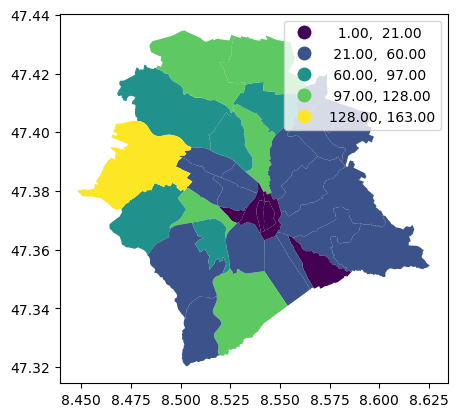

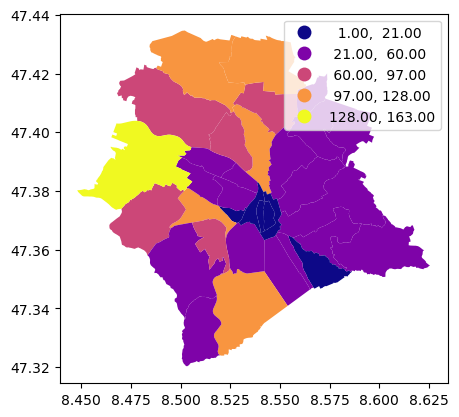

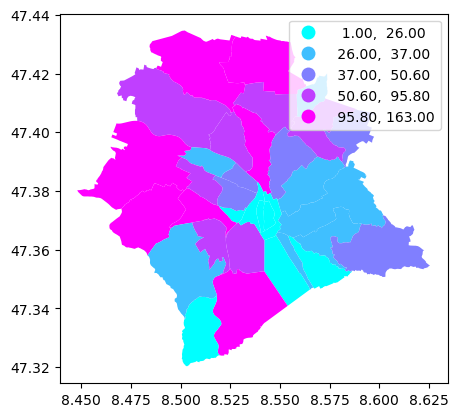

In [45]:
# Plot by StatQuartiere
# Weitere Schemes: scheme='quantiles', scheme='fisherjenks', scheme='natural_breaks',

stadtquartiere_shapes_joined.plot(column='AnzGebuWir', cmap='viridis', scheme='natural_breaks', legend=True )
#scheme werte: https://matplotlib.org/2.0.2/users/colormaps.html

stadtquartiere_shapes_joined.plot(column='AnzGebuWir', cmap='plasma', scheme='fisherjenks', legend=True )
#scheme werte: https://matplotlib.org/2.0.2/users/colormaps.html
stadtquartiere_shapes_joined.plot(column='AnzGebuWir', cmap='cool', scheme='quantiles', legend=True )
#scheme werte: https://matplotlib.org/2.0.2/users/colormaps.html

#
#Neuere Gallerie: https://matplotlib.org/stable/gallery/index.html

Noch zu prüfen, folgendes schöne Beispiel: https://docs.bokeh.org/en/latest/docs/user_guide/interaction/legends.html

Konkrete Beispiele von Bookeh in Jupyter NB: https://docs.bokeh.org/en/latest/docs/user_guide/jupyter.html

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](http://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/EditForm.aspx?ID=157&Source=%2Forga%2Fssz%2Dprodukte%2FLists%2FSASA%5FOutputs)**